# 07 — Arc Analysis

Detect and quantify the rise-and-fall of abstract language across literary history.

Uses two regression approaches:
- **Quadratic**: `score ~ year + year²` — tests for inverted-U, estimates peak year
- **Piecewise linear**: two slopes with optimal breakpoint — measures abstracting/concretizing rates

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.insert(0, '..')
from abstraction.analysis import *
from abstraction.plotting import plot_arc, plot_arc_by_genre

## Load all scored corpora

Single load used throughout the notebook.

In [3]:
combined = load_all_scored()
print(f'{len(combined)} texts, {combined.year.min():.0f}-{combined.year.max():.0f}, {combined.corpus_name.nunique()} corpora')
combined.genre_harmonized.value_counts()

Loading hathi_englit:  57%|█████▊    | 23/40 [00:27<00:17,  1.05s/it]  

  Skipping hathi: No metadata found at /Users/rj416/lltk_data/corpora/hathi


Loading txtlab: 100%|██████████| 40/40 [00:30<00:00,  1.29it/s]           


1431936 texts, -800-9179, 33 corpora


genre_harmonized
Periodical             396988
Poetry                 355231
Fiction                269874
Primary Document       178364
Spoken                  75204
                        37567
Drama                   28861
Criticism               24994
Academic                24048
Essay/Treatise          11096
Nonfiction              10427
Sermon                   6007
Letters                  5221
Biography                3894
Film                      967
Fictional Dialogue        868
Fictional Narration       868
Legal                     636
Political                 227
Dialogue                  176
Oratory                   173
novel                     106
Miscellany                 41
Other                      37
stories                    14
Juvenilia                  10
theatre                     8
autobio                     7
folktales                   7
poetry_mod                  4
essay                       4
poetry_trad                 3
history                

## Canon Fiction: full arc

In [4]:
# Filter canon fiction from combined
df = combined[combined.corpus_name == 'canon_fiction'].copy()
print(f'{len(df)} texts, {df.year.min()}-{df.year.max()}')
df[['id', 'year', 'major_genre', 'Abs-Conc.Median.median']].head()

1803 texts, -800.0-2019.0


,id,year,major_genre,Abs-Conc.Median.median
49461,Addison.Spectator,1711.0,Other,-0.414567
49462,Ammianus.History,391.0,History,-0.348566
49463,AngloSaxon.Beowulf,1000.0,Epic,0.044100
49464,AngloSaxon.Dream of the Rood,900.0,Verse,-0.042556
49465,Anon.1001Nights.1914,900.0,Novella,-0.013767


In [5]:
# Fit the arc (all years)
result = fit_arc(df)
print(summarize_arc(result))

=== ? (1713 texts, 40 bins, 1600-1990) ===
  Quadratic: abstractness rises then falls (expected arc) ***, peak abstractness ~1713, R²=0.850
  Piecewise (break 1760): before abstracting -0.1341/century ***, after concretizing +0.3423/century ***, R²=0.896


In [6]:
# Restrict to 1500+ (avoid ancient outliers pulling the peak)
result_1500 = fit_arc(df, min_year=1500)
print(summarize_arc(result_1500))

=== ? (1731 texts, 42 bins, 1500-1990) ===
  Quadratic: abstractness rises then falls (expected arc) ***, peak abstractness ~1696, R²=0.801
  Piecewise (break 1760): before abstracting -0.1253/century ***, after concretizing +0.3371/century ***, R²=0.871


## Across norm columns

Does the arc hold regardless of which norm we use?

In [7]:
score_cols = get_score_columns(df)
rows = []
for col in score_cols:
    r = fit_arc(df[df.year >= 1500], score_col=col)
    r['score_col'] = col
    rows.append(r)

norms_df = pd.DataFrame(rows)
# Show: which norms show the expected arc (β₂ > 0 = concreteness U = abstractness inverted-U)
norms_df['has_arc'] = (norms_df['quad_beta2'] > 0) & (norms_df['quad_beta2_p'] < 0.05)
summary = norms_df[['score_col', 'quad_beta2', 'quad_beta2_p', 'quad_peak_year', 'quad_r2', 'has_arc']]
print(f"Norms showing expected arc: {summary.has_arc.sum()} / {len(summary)}")
summary.sort_values('quad_r2', ascending=False)

Norms showing expected arc: 56 / 56


,score_col,quad_beta2,quad_beta2_p,quad_peak_year,quad_r2,has_arc
6,Abs-Conc.LSN-Hapt.orig,0.000007,3.826461e-11,1715.438460,0.886255,True
4,Abs-Conc.LSN-Hapt.C20,0.000009,5.528288e-10,1705.261913,0.882564,True
39,Abs-Conc.Median.C20,0.000009,1.448019e-09,1706.793492,0.871155,True
46,Abs-Conc.PAV-Conc.C20,0.000009,3.888867e-09,1702.676758,0.869382,True
18,Abs-Conc.MRC-Conc.C20,0.000009,2.283450e-09,1705.674233,0.868919,True
32,Abs-Conc.MT-Conc.C20,0.000009,1.228244e-09,1708.779730,0.868902,True
3,Abs-Conc.LSN-Hapt.C19,0.000009,3.635672e-09,1703.797988,0.867929,True
0,Abs-Conc.LSN-Hapt.C16,0.000009,7.860418e-09,1699.984968,0.867357,True
41,Abs-Conc.Median.orig,0.000007,3.845021e-10,1715.099613,0.867289,True
11,Abs-Conc.LSN-Imag.C20,0.000009,4.708049e-09,1704.013367,0.864912,True


## By genre

Does the arc appear within individual genres?

In [8]:
genre_rows = []
for genre, gdf in df[df.year >= 1600].groupby('major_genre'):
    if len(gdf) < 30:
        continue
    r = fit_arc(gdf, score_col='Abs-Conc.Median.median')
    r['genre'] = genre
    genre_rows.append(r)

genre_df = pd.DataFrame(genre_rows)
genre_df['has_arc'] = (genre_df['quad_beta2'] > 0) & (genre_df['quad_beta2_p'] < 0.05)
for _, row in genre_df.iterrows():
    row_d = row.to_dict()
    row_d['corpus'] = row_d.get('genre', '?')
    print(summarize_arc(row_d))
    print()

=== Novel (695 texts, 27 bins, 1720-1990) ===
  Quadratic: abstractness rises then falls (expected arc) n.s., peak abstractness ~1004, R²=0.902
  Piecewise (break 1820): before concretizing +0.2772/century **, after concretizing +0.3600/century ***, R²=0.903

=== Romance (45 texts, 7 bins, 1630-1710) ===
  Quadratic: insufficient data
  Piecewise: insufficient data



## All scored corpora

Run arc fitting across every corpus in `data/scores/v7/`.

In [9]:
# All corpora, per-corpus arc fitting (reuses combined)
all_results = fit_arc_all_corpora(combined_df=combined, min_year=1600)
all_results['has_arc'] = (all_results['quad_beta2'] > 0) & (all_results['quad_beta2_p'] < 0.05)
all_results[['corpus', 'n_texts', 'year_min', 'year_max', 'quad_peak_year', 'quad_beta2_p', 'quad_r2', 'has_arc', 'pw_break_year', 'pw_slope_before', 'pw_slope_after']].sort_values('quad_r2', ascending=False)

,corpus,n_texts,year_min,year_max,quad_peak_year,quad_beta2_p,quad_r2,has_arc,pw_break_year,pw_slope_before,pw_slope_after
6,chicago,18178,1880.0,2000.0,2002.384199,7.169951e-05,0.984475,False,NaN,NaN,NaN
16,gale_amfic,18175,1780.0,1920.0,2067.822320,1.854287e-01,0.955256,False,NaN,NaN,NaN
22,litlab,5397,1700.0,1990.0,1738.582825,2.730121e-06,0.917212,True,1790.0,-0.001420,0.003597
19,hathi_englit,178176,1700.0,1920.0,1762.333069,2.788073e-07,0.911233,True,1820.0,-0.000166,0.002776
18,hathi_bio,3572,1700.0,1990.0,1739.169212,8.173507e-05,0.871076,True,1810.0,-0.000276,0.002488
10,dialnarr,1736,1820.0,1940.0,1259.783339,8.362834e-01,0.862970,False,NaN,NaN,NaN
2,canon_fiction,1713,1600.0,1990.0,1712.735900,3.587488e-09,0.849626,True,1760.0,-0.001341,0.003423
5,chadwyck_poetry,271859,1600.0,1990.0,1672.645441,7.546280e-06,0.828987,True,1720.0,-0.001483,0.002369
23,long_arc_prestige,3658,1810.0,1940.0,1822.098522,5.435911e-02,0.804187,False,NaN,NaN,NaN
32,tedjdh,3778,1700.0,1890.0,2111.561777,5.312223e-01,0.786007,False,1790.0,0.001605,0.001571


## Cross-corpus arc by genre (with corpus fixed effects)

Pool all scored corpora, harmonize genres, and fit one arc per genre with corpus dummy variables absorbing baseline differences.

In [10]:
genre_results = fit_arc_all_by_genre(combined_df=combined, corpus_fixed_effects=True)
for _, row in genre_results.iterrows():
    print(summarize_arc(row.to_dict()))
    print()

=== Academic (9940 texts, 2 bins, 1 corpora, 1990-2000) ===
  Quadratic: insufficient data
  Piecewise: insufficient data

=== Biography (3890 texts, 60 bins, 4 corpora, 1700-1990) ===
  Quadratic: abstractness rises then falls (expected arc) ***, peak abstractness ~1772, R²=0.716
  Piecewise (break 1810): before abstracting -0.0922/century *, after concretizing +0.2585/century ***, R²=0.743

=== Criticism (17527 texts, 41 bins, 1 corpora, 1600-2000) ===
  Quadratic: abstractness rises then falls (expected arc) n.s., peak abstractness ~1594, R²=0.115
  Piecewise (break 1690): before abstracting -0.0682/century n.s., after concretizing +0.0309/century **, R²=0.186

=== Dialogue (145 texts, 16 bins, 1 corpora, 1600-1750) ===
  Quadratic: abstractness rises then falls (expected arc) n.s., peak abstractness ~1679, R²=0.236
  Piecewise: insufficient data

=== Drama (25825 texts, 125 bins, 7 corpora, 1600-2000) ===
  Quadratic: abstractness rises then falls (expected arc) ***, peak abstractn

## Corpus-adjusted arc plots

Remove corpus-level baseline differences and plot the shared time trend. Adjusted points are shifted to a common baseline; the black line is the fitted trend (quadratic or piecewise).

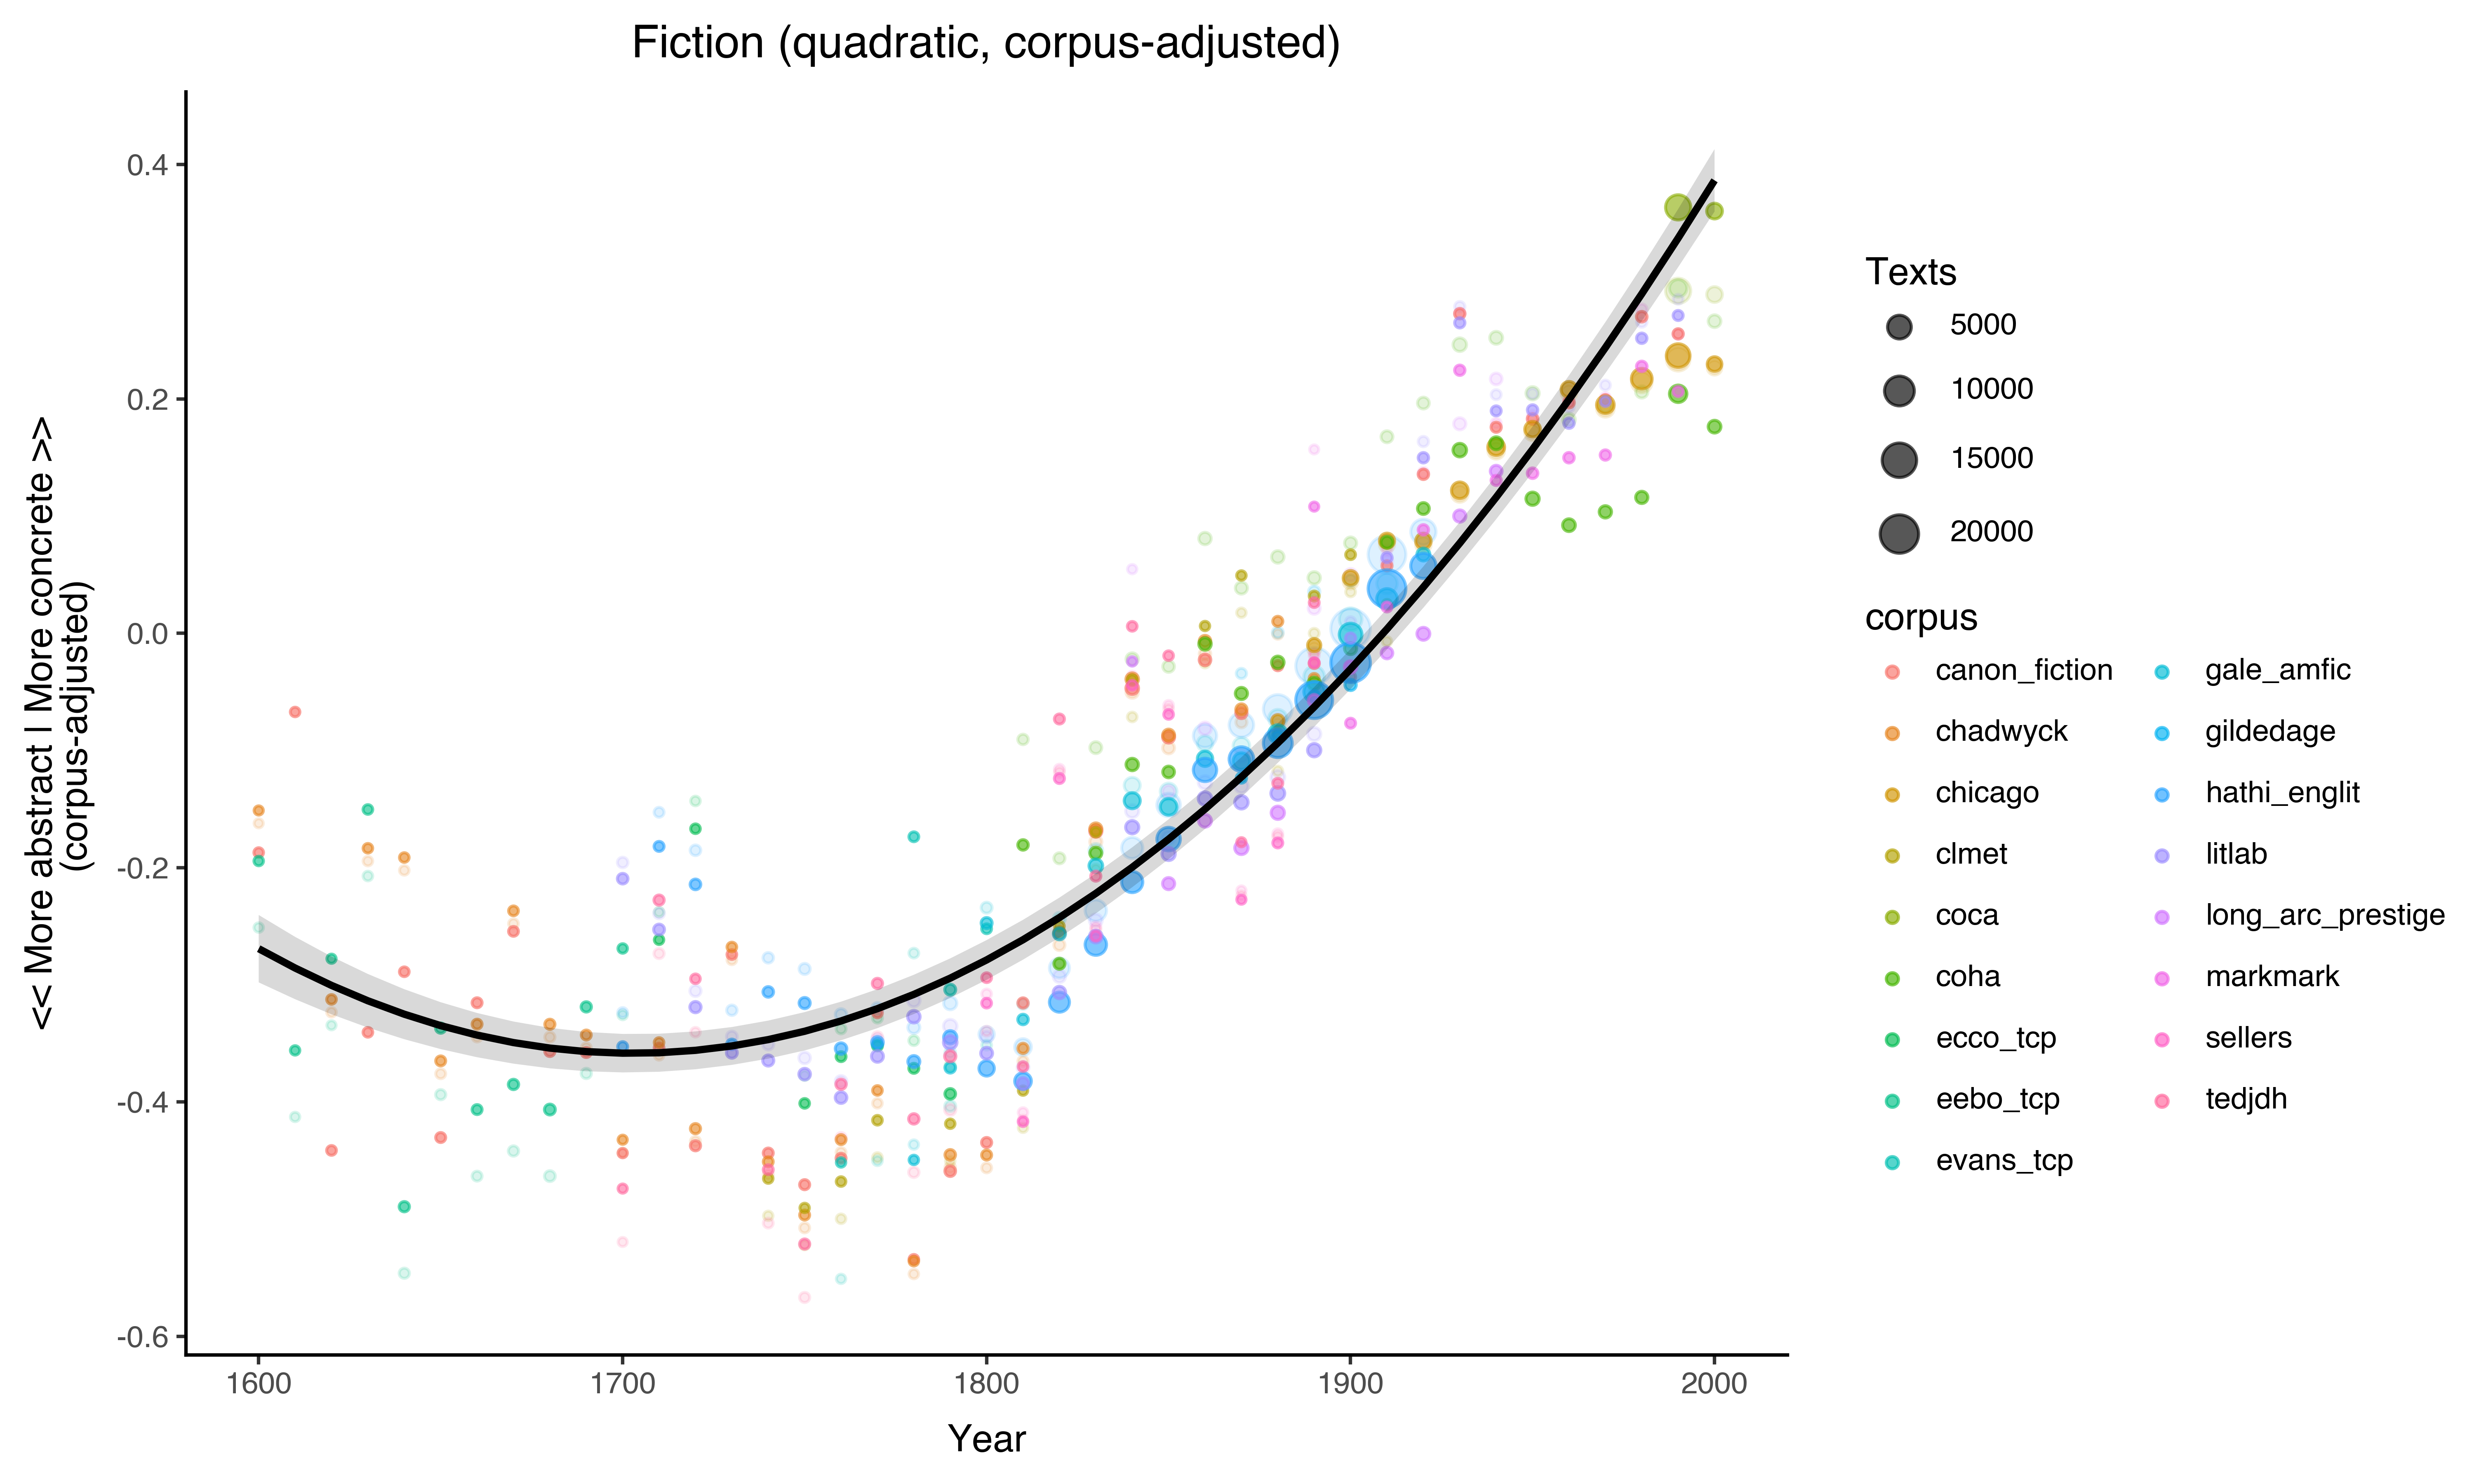

In [11]:
# Single genre: Fiction (quadratic)
fiction = combined[combined.genre_harmonized == 'Fiction']
adj = adjust_scores(fiction, model='quadratic')
plot_arc(adj, title='Fiction (quadratic, corpus-adjusted)')

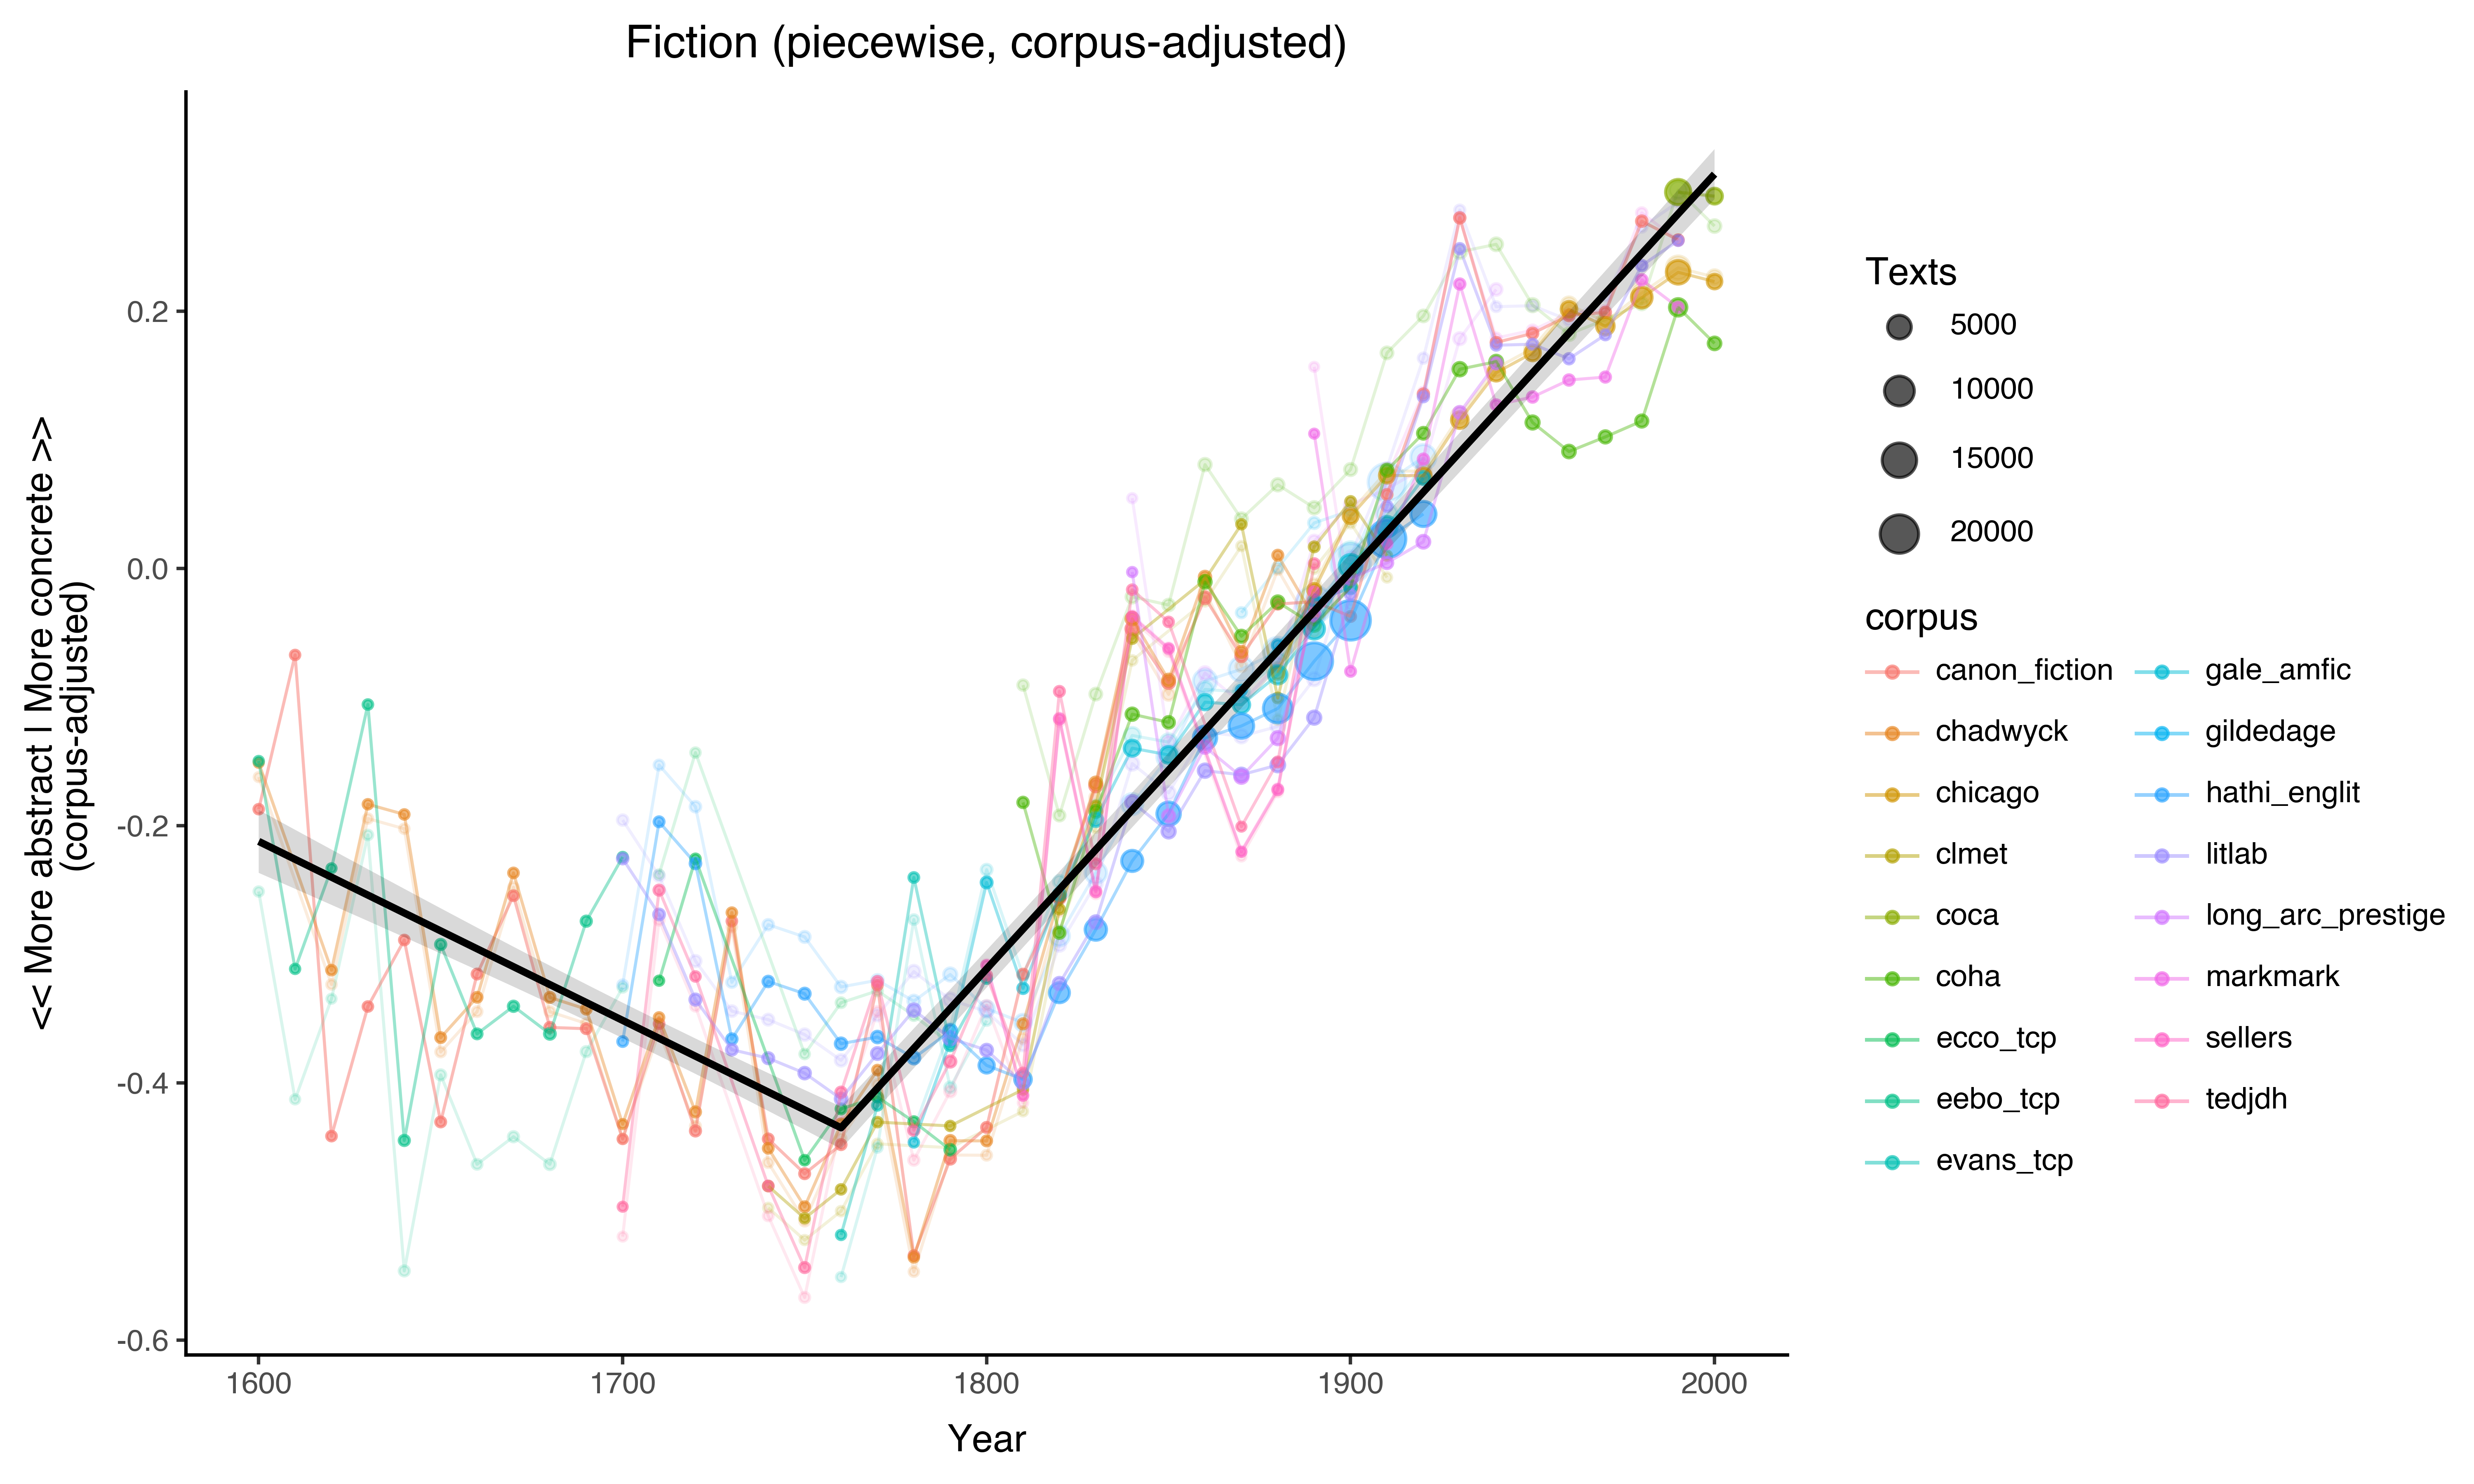

In [12]:
# Single genre: Fiction (piecewise)
adj_pw = adjust_scores(fiction, model='piecewise')
plot_arc(adj_pw, title='Fiction (piecewise, corpus-adjusted)', show_lines=True)

In [13]:
genres = {'Periodical', 'Poetry', 'Fiction'}
combined2 = combined[combined.genre_harmonized.isin(genres)].drop_duplicates(subset=['corpus_name', 'id'])

In [14]:
combined2.year.min()

np.float64(-800.0)

In [15]:
combined2.groupby(['genre_harmonized', 'corpus_name']).size().reset_index(name='n_texts').sort_values(['genre_harmonized', 'n_texts'], ascending=[True, False]).set_index(['genre_harmonized', 'corpus_name'])

n_texts
genre_harmonized corpus_name               
Fiction          hathi_englit        101931
                 coca                 22577
                 gale_amfic           18199
                 coha                  9965
                 chicago               9089
                 internet_archive      7815
                 litlab                5409
                 canon_fiction         1802
                 chadwyck              1294
                 long_arc_prestige     1242
                 tedjdh                 405
                 markmark               353
                 gildedage              334
                 eebo_tcp               263
                 ecco_tcp               131
                 clmet                  127
                 evans_tcp              118
                 sellers                111
Periodical       coca                128218
                 coha                102966
                 bpo                  49305
                 new_yorker            4506
                 spectator              810
Poetry           chadwyck_poetry     284943
                 hathi_englit         58281
                 eebo_tcp              9001
                 tedjdh                 820
                 long_arc_prestige      721
                 sellers                335
                 ecco_tcp               319
                 evans_tcp              132

In [16]:
# All genres, faceted (quadratic)
# plot_arc_by_genre(combined2, model='quadratic', show_lines=True)

In [17]:
# All genres, faceted (piecewise)
# plot_arc_by_genre(combined2, model='piecewise', show_lines=True)

In [18]:
# All genres, combined (no facet) — color by genre, shape by corpus
import plotnine as p9
fig = plot_arc_by_genre(combined2, model='piecewise', show_facet=False, show_lines=False, show_raw=True)
colors = {
    'Fiction': '#222222',     # darkest gray
    'Poetry':  '#666666',     # medium gray
    'Periodical': '#bbbbbb',  # lighter gray, but not pure white
}
fig+=p9.scale_color_manual(values=colors)
fig+=p9.scale_fill_manual(values=colors)
fig+=p9.theme(figure_size=(8, 6))
fig+=p9.theme(legend_position="right")
fig.save('../figures/arc-by-3genres-piecewise.png')

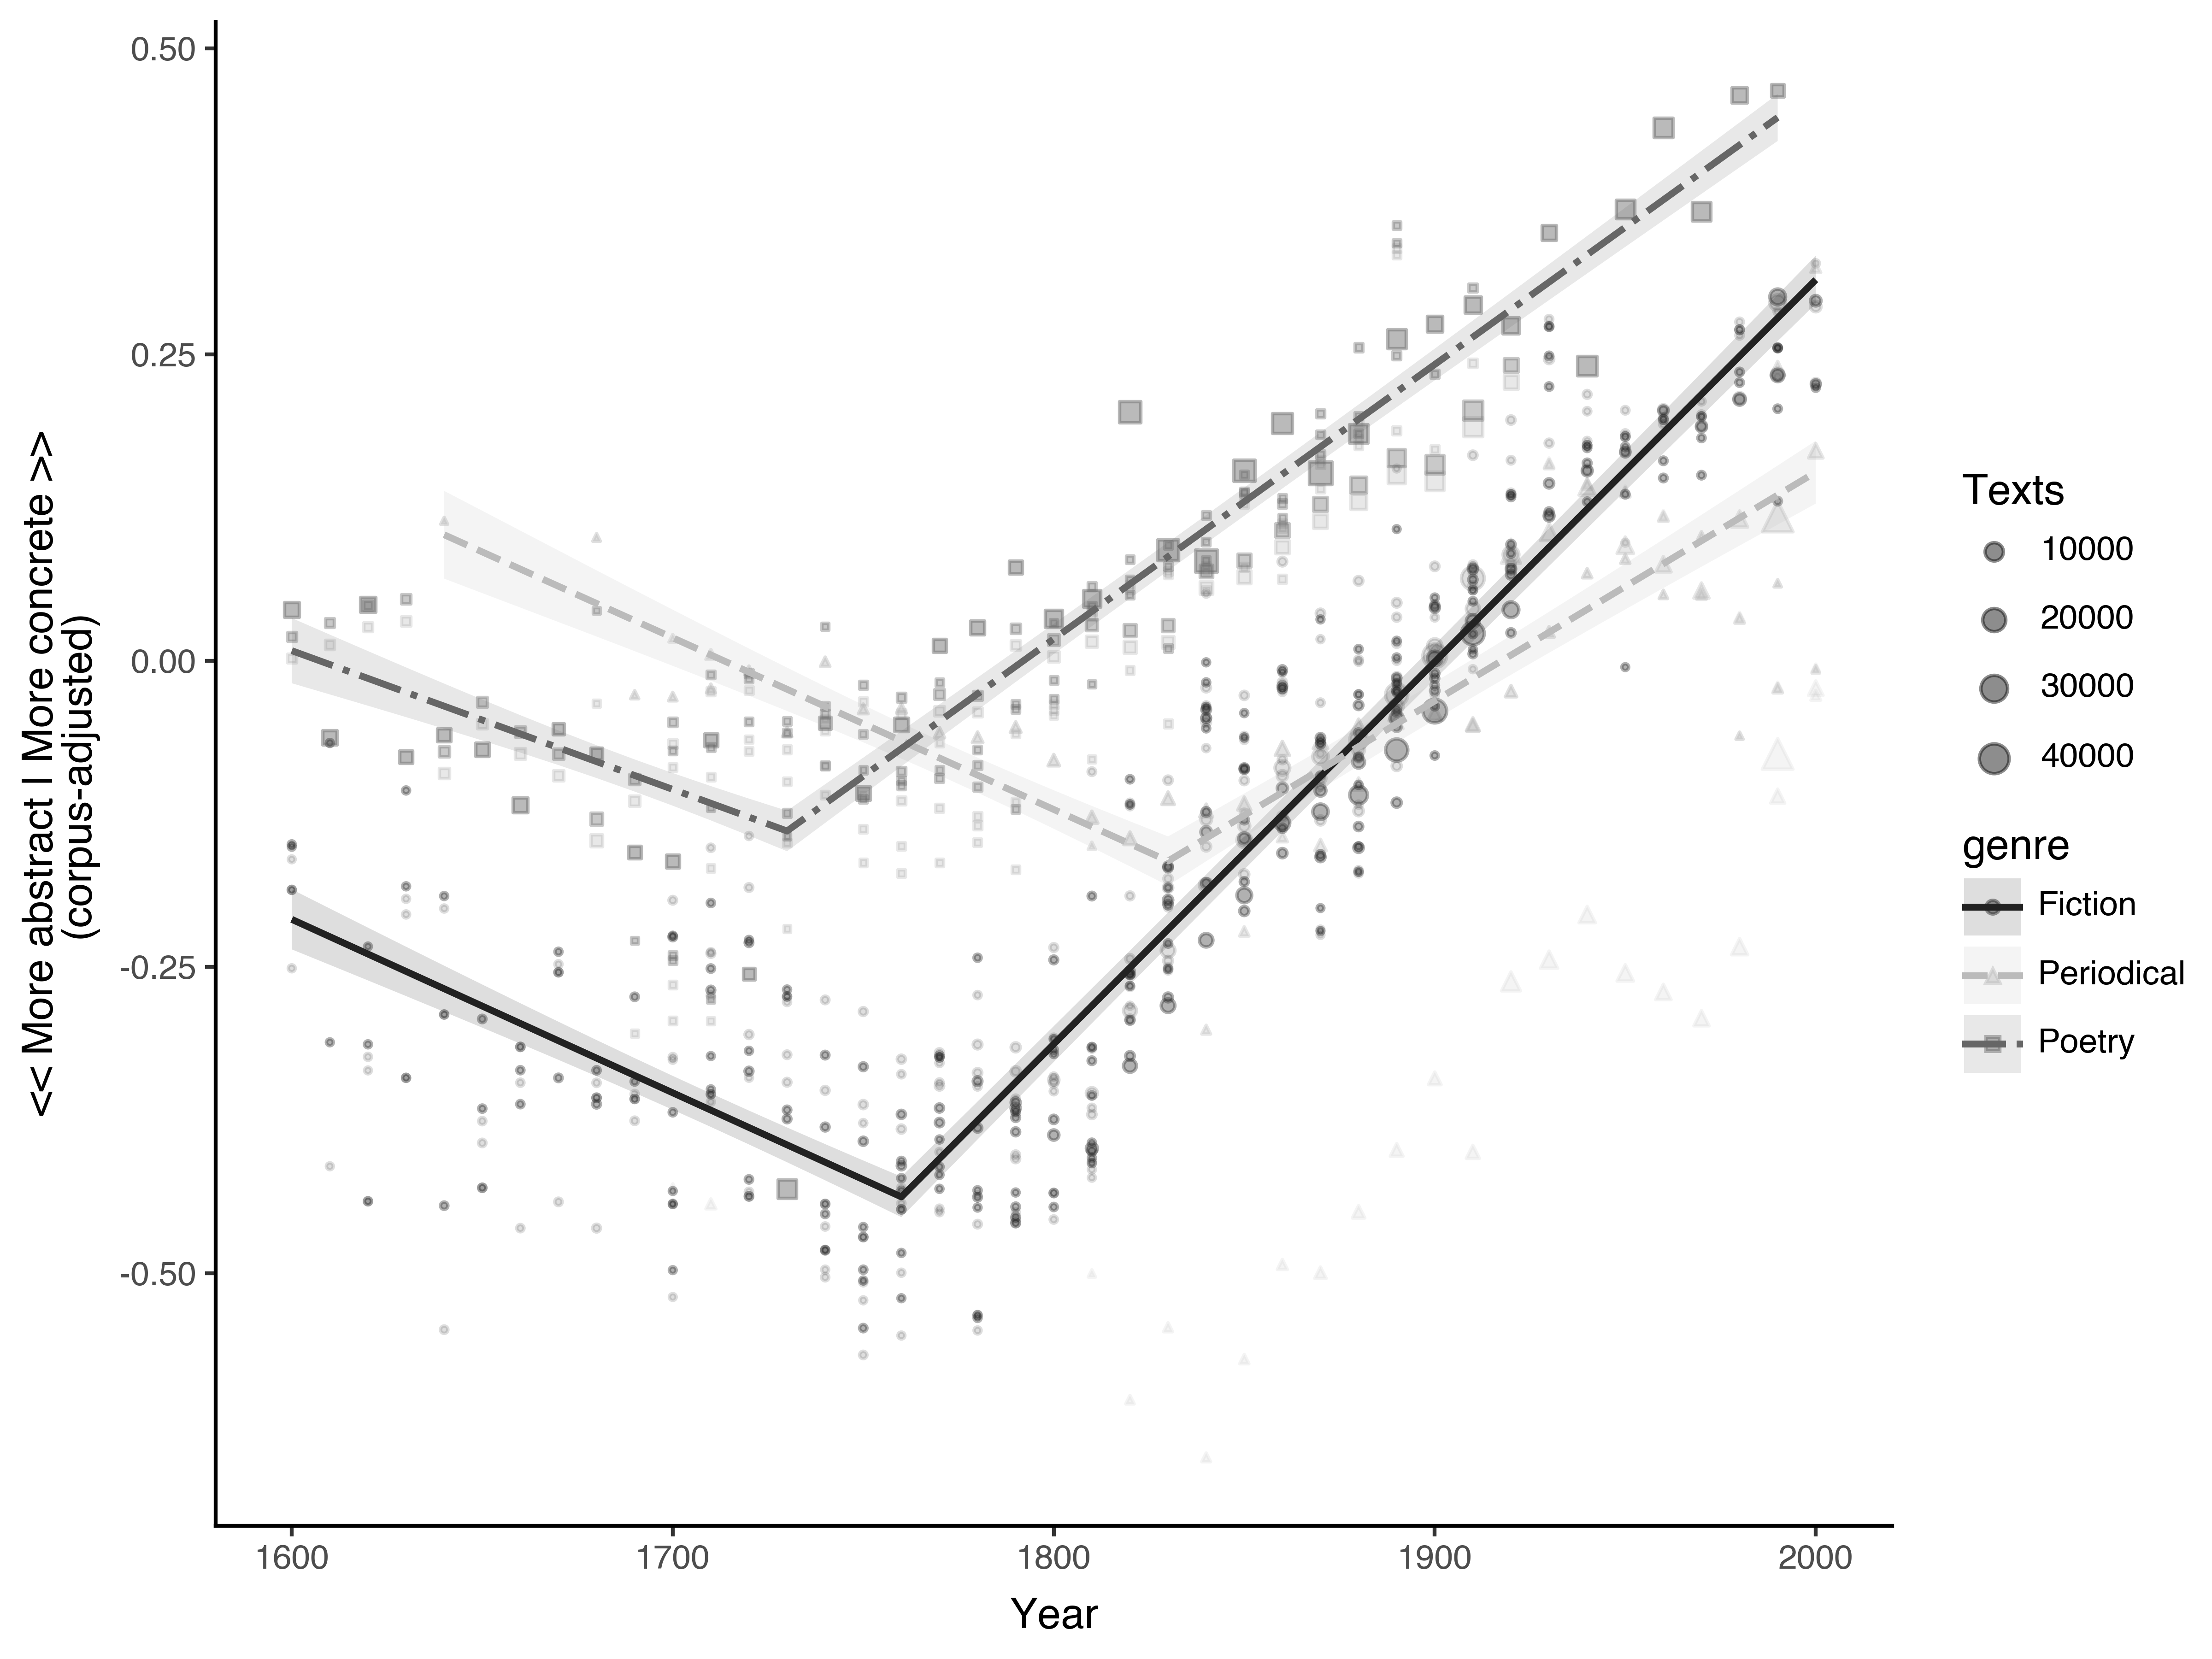

In [19]:
fig

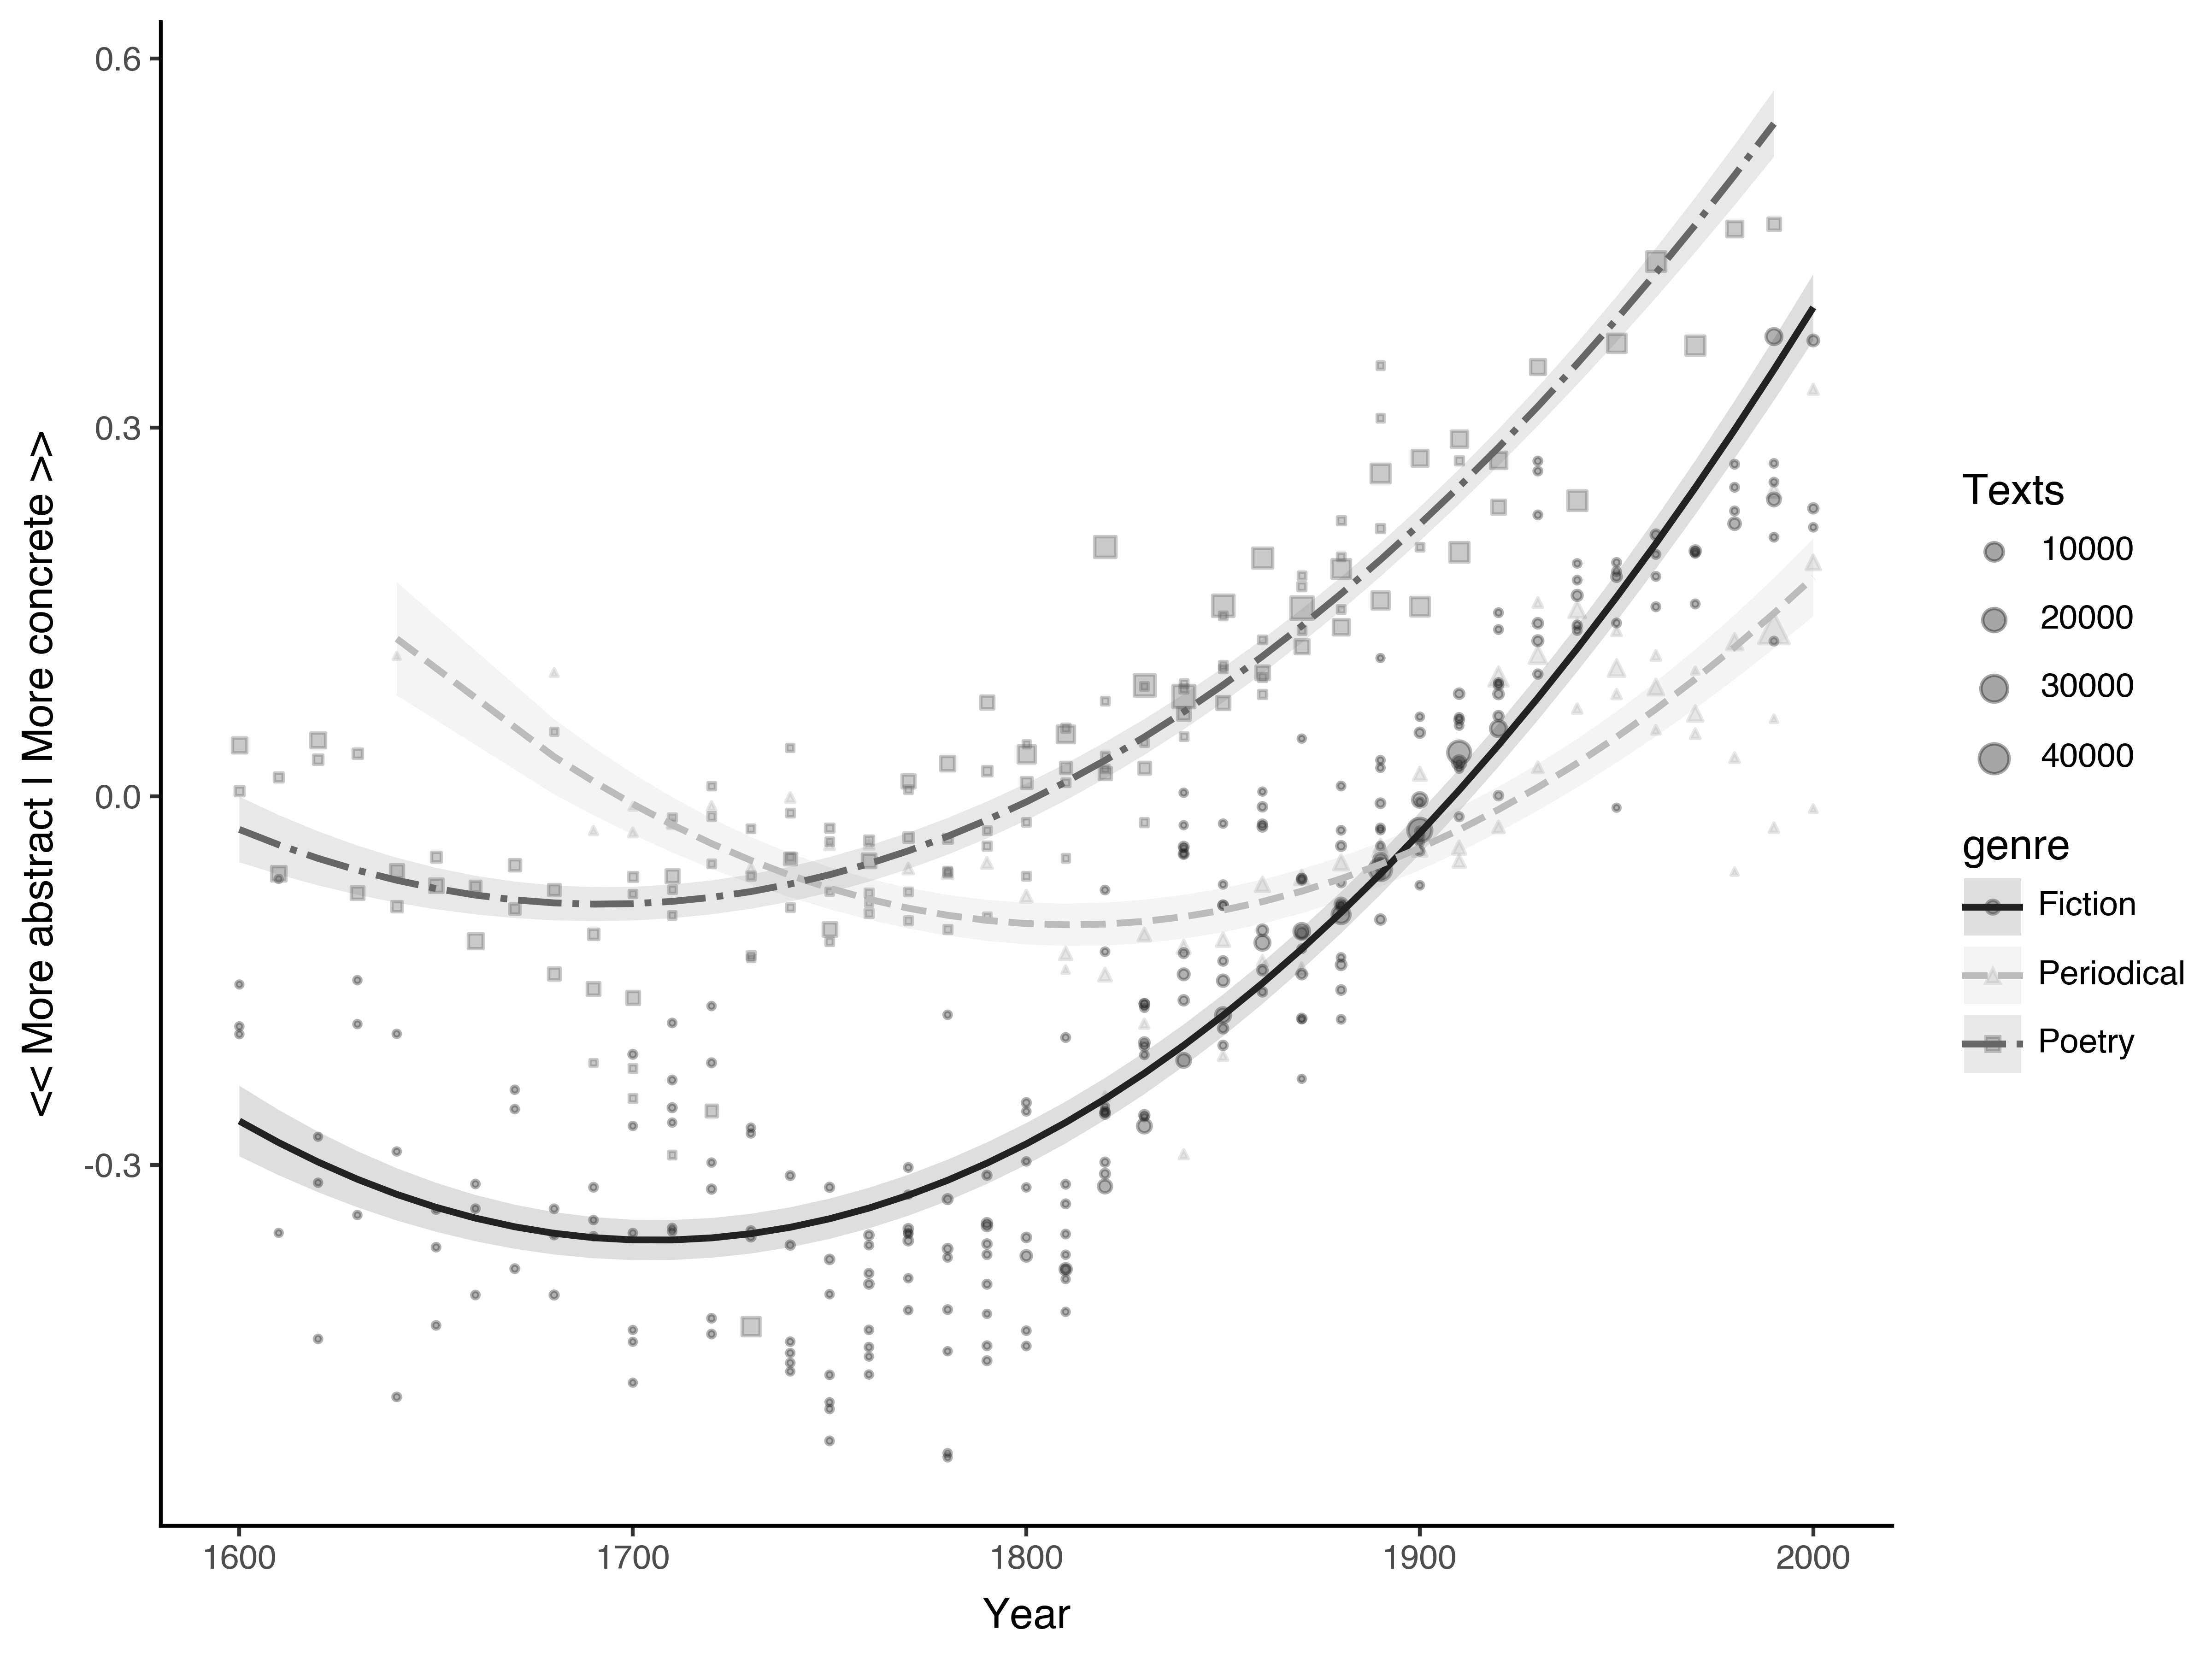

In [39]:
# All genres, combined (no facet) — color by genre, shape by corpus
fig=plot_arc_by_genre(combined2, model='quadratic', show_facet=False, show_lines=False, min_year=1600, max_year=2000)
fig+=p9.scale_color_manual(values=colors)
fig+=p9.scale_fill_manual(values=colors)
fig+=p9.theme(figure_size=(8, 6))
fig+=p9.theme(legend_position="right")
fig.save('../figures/arc-by-3genres-quadratic.png')
fig

In [40]:
combined2.genre_harmonized.value_counts()

genre_harmonized
Poetry        354552
Periodical    285805
Fiction       181165
Name: count, dtype: int64

In [86]:
import textwrap
def arc_caption(combined_df, genres=None, wrap_by=160):
    """Generate a caption string summarizing texts per genre and corpus.

    Parameters
    ----------
    combined_df : DataFrame
        Combined scored DataFrame with genre_harmonized and corpus_name columns.
    genres : list, optional
        Genres to include. If None, uses all genres present.

    Returns
    -------
    str
        Caption like "Fiction (45,231 texts: hathi_englit 30,102, chadwyck 5,012, ...); ..."
    """
    df = combined_df
    if genres is not None:
        df = df[df["genre_harmonized"].isin(genres)]

    parts = []
    for genre in sorted(df["genre_harmonized"].dropna().unique()):
        gdf = df[df["genre_harmonized"] == genre]
        corpus_counts = gdf["corpus_name"].value_counts()
        corpus_str = " + ".join(
            f"{name.replace('_', ' ').title()} ({count:,})" for name, count in corpus_counts.items()
        )
        opart = f"- {genre}: {len(gdf):,} texts = {corpus_str}"
        parts.append(opart)
    
    # Format output using textwrap to wrap lines at 80 characters
    def _wrap(part):
        return textwrap.fill(part, width=wrap_by, break_long_words=False, break_on_hyphens=False)
    
    out = "\n\n".join(_wrap(part).replace("\n", "\n        ") for part in parts)
    return out

In [87]:
caption = arc_caption(combined2, wrap_by=160)
print(caption)

- Fiction: 181,165 texts = Hathi Englit (101,931) + Coca (22,577) + Gale Amfic (18,199) + Coha (9,965) + Chicago (9,089) + Internet Archive (7,815) + Litlab
        (5,409) + Canon Fiction (1,802) + Chadwyck (1,294) + Long Arc Prestige (1,242) + Tedjdh (405) + Markmark (353) + Gildedage (334) + Eebo Tcp (263) + Ecco Tcp
        (131) + Clmet (127) + Evans Tcp (118) + Sellers (111)

- Periodical: 285,805 texts = Coca (128,218) + Coha (102,966) + Bpo (49,305) + New Yorker (4,506) + Spectator (810)

- Poetry: 354,552 texts = Chadwyck Poetry (284,943) + Hathi Englit (58,281) + Eebo Tcp (9,001) + Tedjdh (820) + Long Arc Prestige (721) + Sellers (335) + Ecco
        Tcp (319) + Evans Tcp (132)


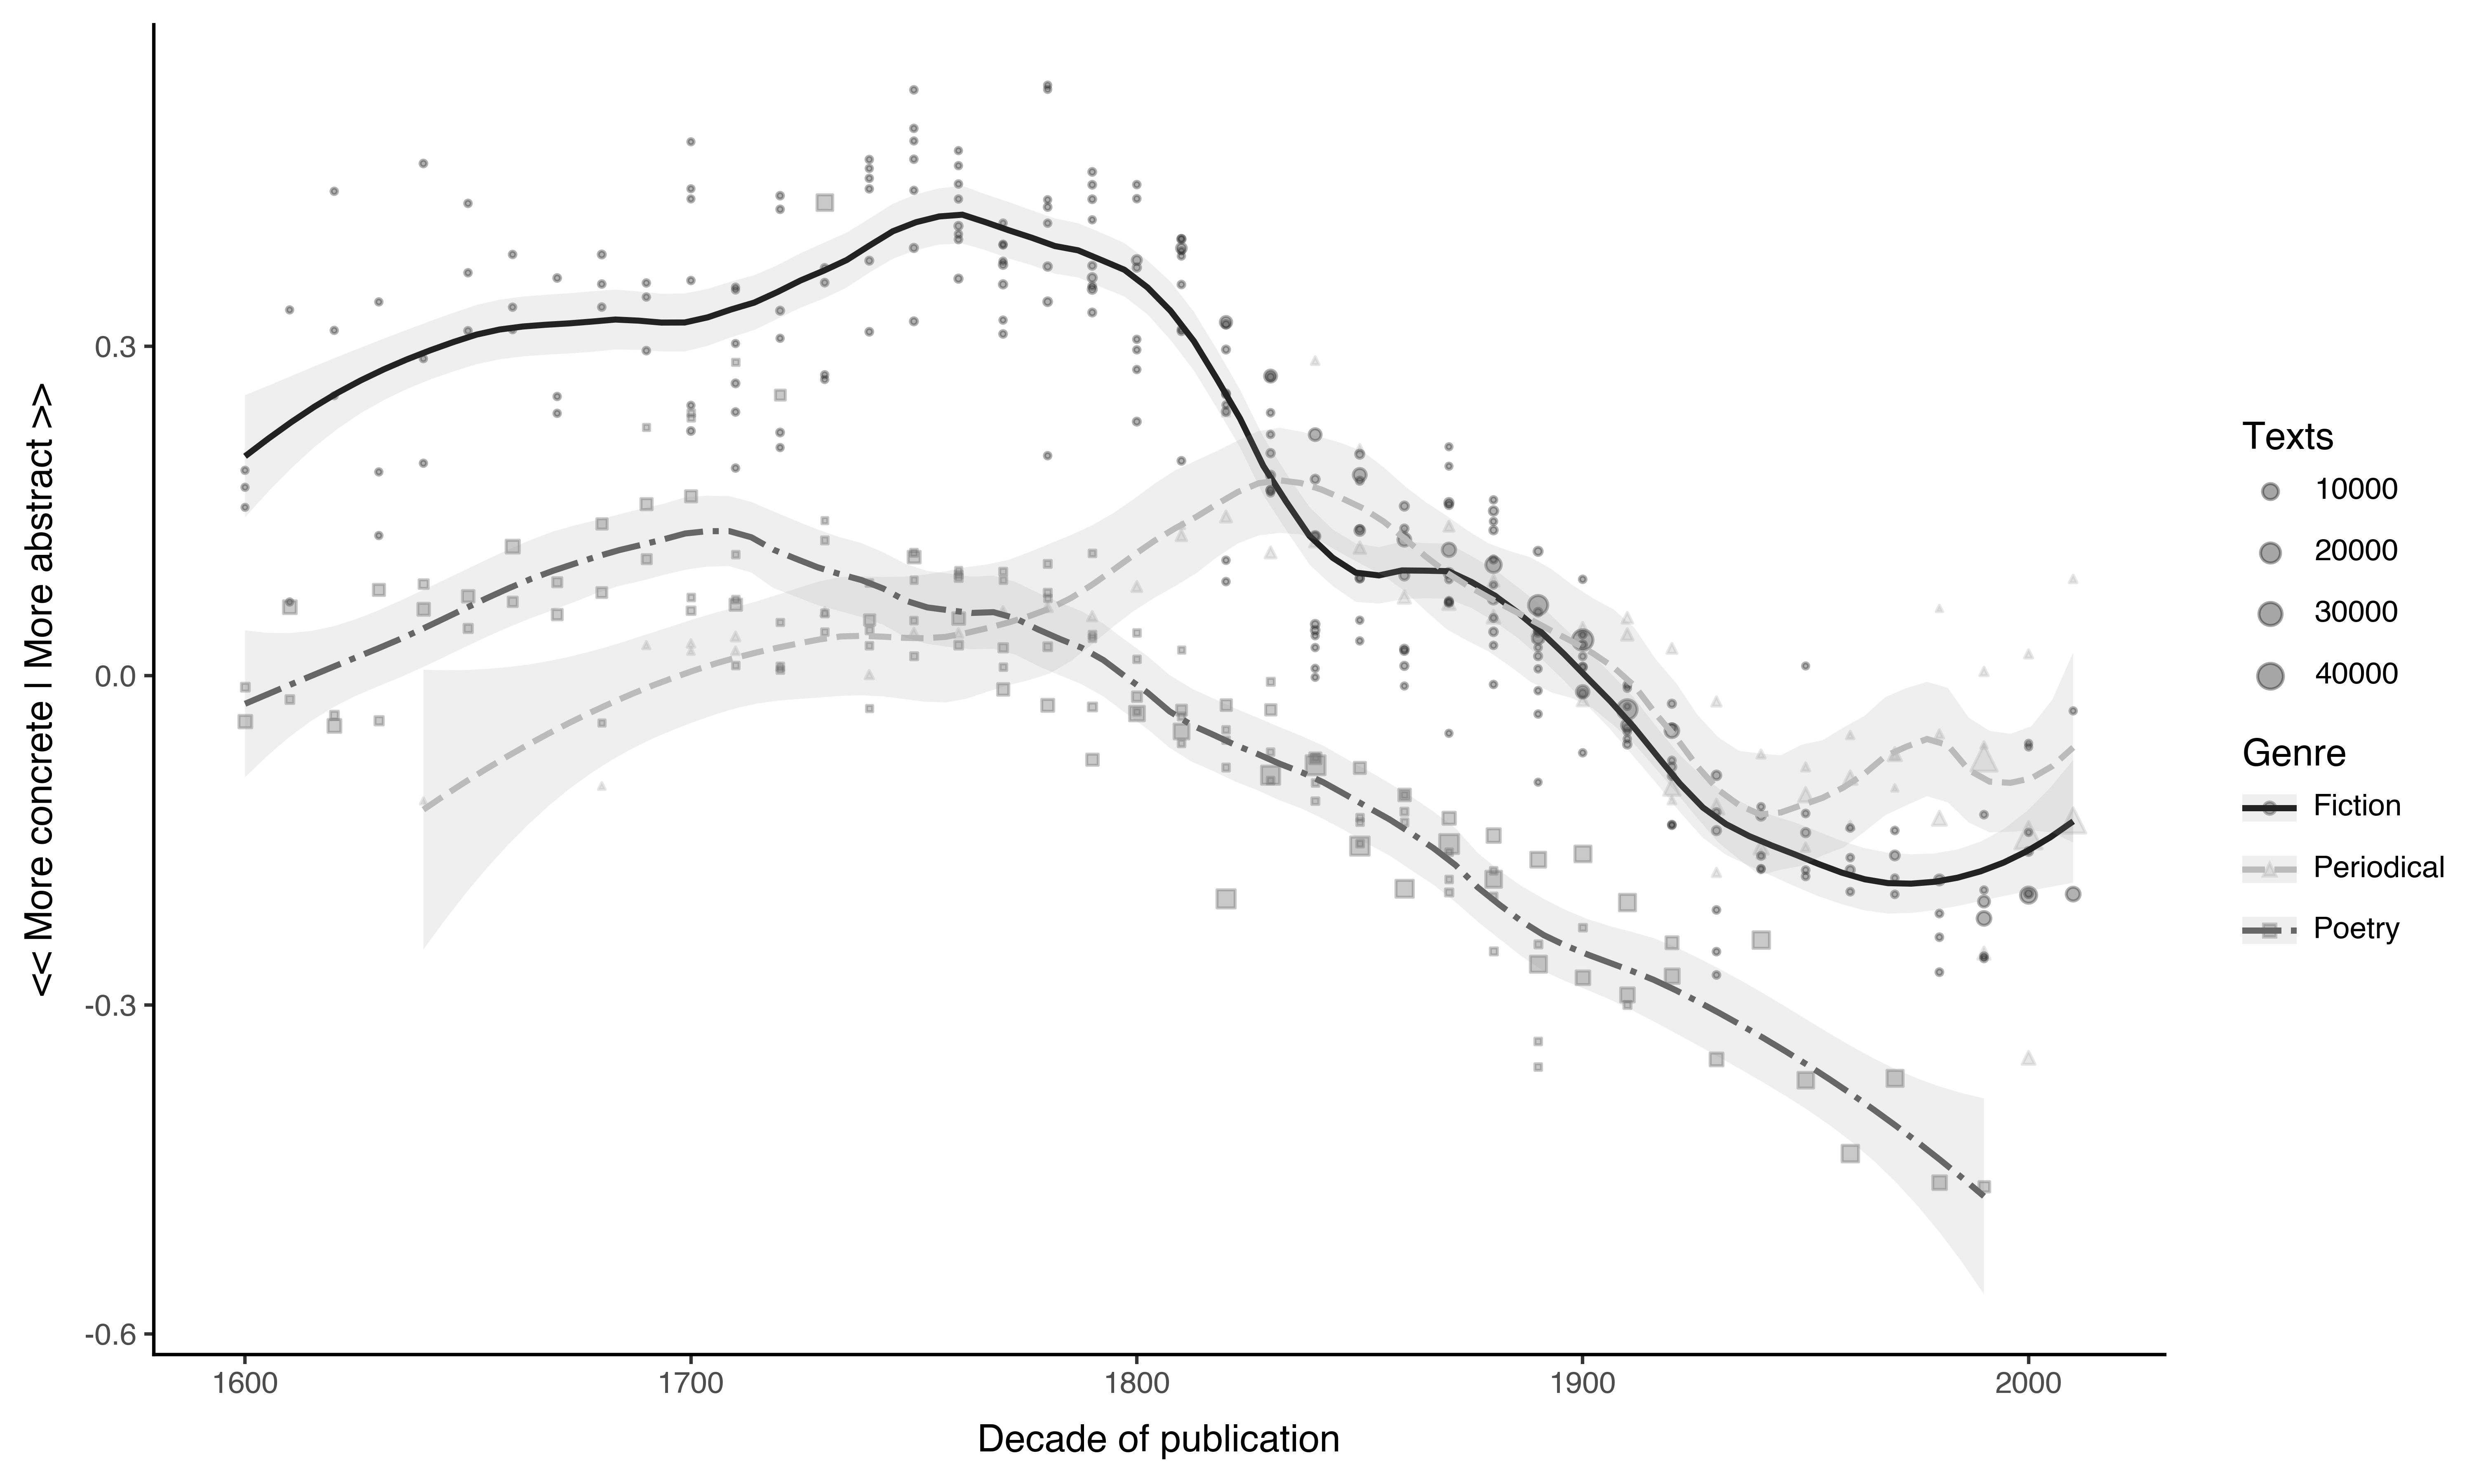

In [ ]:
fig=plot_arc_by_genre(
    combined2, 
    model='cubic', 
    show_facet=False, 
    show_fit=False, 
    show_loess=True, 
    show_lines=False, 
    min_year=1600, 
    max_year=2020, 
    invert=True
)
fig+=p9.scale_color_manual(values=colors)
fig+=p9.scale_fill_manual(values=colors)
# fig+=p9.theme_minimal()
fig+=p9.theme(
    figure_size=(10, 6),
    legend_position="right",
    # plot_background=p9.element_rect(fill="white"),
    panel_background=p9.element_rect(fill="white"),
    plot_caption = p9.element_text(size=8)
)

caption1 = '    ' + (caption.replace('\n', '\n    '))
caption2 = f'''Data:
{caption1}

Method: Historically-situated concreteness scores per word calculated using historical word embedding models, seeded by concreteness norms from Brysbaert et al 
and other sources. A text is modeled as a weighted average of its word concreteness scores, weighted by word frequency in the text.

Adjustment: Each text is scored by decade and corpus, then corpus-level intercepts are removed via OLS fixed effects so that corpora with systematically higher 
or lower scores do not shift the trend. The plotted points show these corpus-adjusted decade means; point size reflects the number of texts in each bin. 
The smooth is a LOESS fit (span = 0.3) on the adjusted points, with 95% confidence band.

Note: Date of publication in Chadwyck Poetry is estimated as author date of birth + 30 years, given inconsistent publication dates in the metadata.'''

fig+=p9.labs(
    x="Decade of publication",
    # title="Abstractness vs. concreteness in literary language across genres, 1600-2020",
    # caption=caption2,
    size='# Texts',
    linetype='Genre',
    shape='Genre',
    color='Genre',
    fill='Genre',
)

fig.save('../figures/arc-by-3genres-loess.inverted.v4.png')
fig

In [89]:
# # All genres, combined (no facet) — color by genre, shape by corpus
# fig=plot_arc_by_genre(combined2, model='quartic', show_facet=False, show_lines=False, min_year=1600, max_year=2020)
# fig+=p9.scale_color_manual(values=colors)
# fig+=p9.scale_fill_manual(values=colors)
# fig+=p9.theme(figure_size=(8, 6))
# fig+=p9.theme(legend_position="right")
# fig.save('../figures/arc-by-3genres-quartic.png')
# fig